# MIQR-CC — Avaliação dos Modelos + Grad-CAM

Este notebook serve para a fase seguinte do trabalho:

1. carregar o dataset `dataset_cleaned`;
2. carregar checkpoints já treinados em `models/*.pth`;
3. avaliar cada modelo no conjunto de teste;
4. gerar tabela comparativa com Accuracy, Precision, Recall e F1 macro;
5. gerar matrizes de confusão;
6. gerar Grad-CAM para o melhor modelo.

> A baseline do enunciado é **F1 macro = 0.738**. A comparação final deve ser feita com o **F1 macro no test set**.


## 0. Instalações necessárias

Executa só se faltar alguma biblioteca.


In [2]:
# Descomenta se precisares
# !pip install monai torchmetrics timm grad-cam seaborn scikit-learn pandas matplotlib

## 1. Imports e configuração

In [1]:

import os
import gc
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from monai.transforms import (
    LoadImage,
    EnsureChannelFirst,
    Resize,
    Compose,
    NormalizeIntensity,
    Lambda,
    ToTensor,
)
from monai.data import DataLoader
from monai.networks.nets import DenseNet121

import torchvision.models as models
from torchvision.models import (
    ResNet50_Weights,
    MobileNet_V2_Weights,
    EfficientNet_B0_Weights,
    EfficientNet_B7_Weights,
)

try:
    import timm
    TIMM_AVAILABLE = True
except Exception:
    TIMM_AVAILABLE = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))


Device: cuda
NVIDIA GeForce RTX 4060


## 2. Caminhos

A estrutura esperada é:

```text
.
├── dataset_cleaned/
│   ├── train/
│   ├── val/
│   └── test/
├── models/
│   ├── resnet50.pth
│   ├── densenet.pth
│   ├── mobilenet_v2.pth
│   └── efficientnet_b7.pth  # opcional
└── results/
```


In [3]:

BASE_DIR = Path("./dataset_cleaned")
MODELS_DIR = Path("./models")
RESULTS_DIR = Path("./results")
RESULTS_DIR.mkdir(exist_ok=True)

assert BASE_DIR.exists(), f"Não encontrei {BASE_DIR.resolve()}"
assert MODELS_DIR.exists(), f"Não encontrei {MODELS_DIR.resolve()}"

phases = ["train", "val", "test"]
class_names = sorted([
    x for x in os.listdir(BASE_DIR / "train")
    if os.path.isdir(BASE_DIR / "train" / x)
])
num_class = len(class_names)

print("Classes:", class_names)
print("Nº classes:", num_class)


Classes: ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
Nº classes: 4


## 3. Carregar paths das imagens e labels

In [4]:

data = {phase: {"images": [], "labels": []} for phase in phases}
valid_exts = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

def load_images_labels(phase):
    for i, class_name in enumerate(class_names):
        class_dir = BASE_DIR / phase / class_name
        image_files = sorted([
            str(class_dir / x)
            for x in os.listdir(class_dir)
            if x.lower().endswith(valid_exts)
        ])
        data[phase]["images"].extend(image_files)
        data[phase]["labels"].extend([i] * len(image_files))

for phase in phases:
    load_images_labels(phase)
    print(f"{phase}: {len(data[phase]['images'])} imagens")


train: 2400 imagens
val: 234 imagens
test: 267 imagens


## 4. Visualizar distribuição das classes

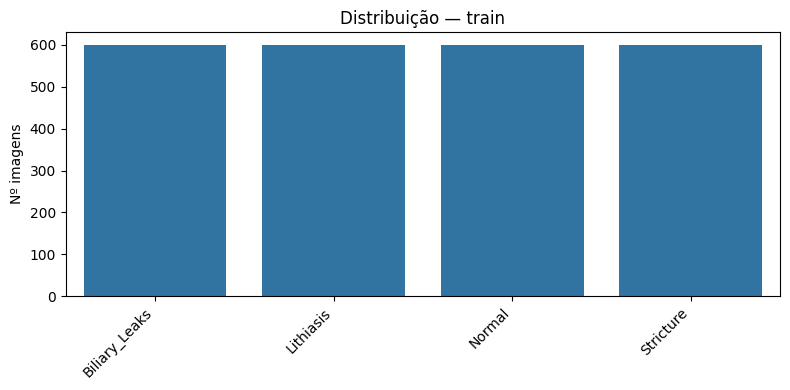

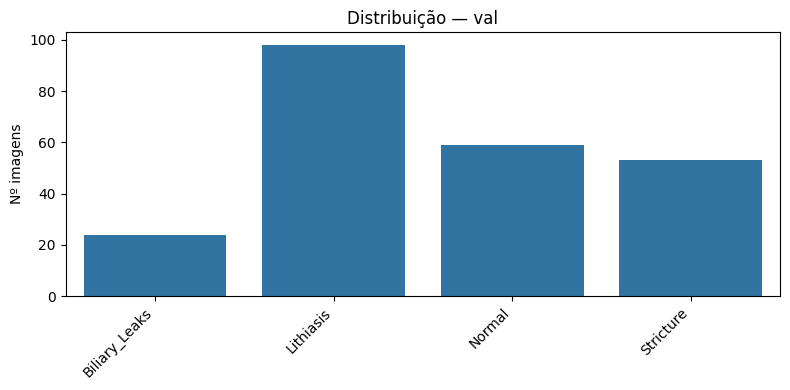

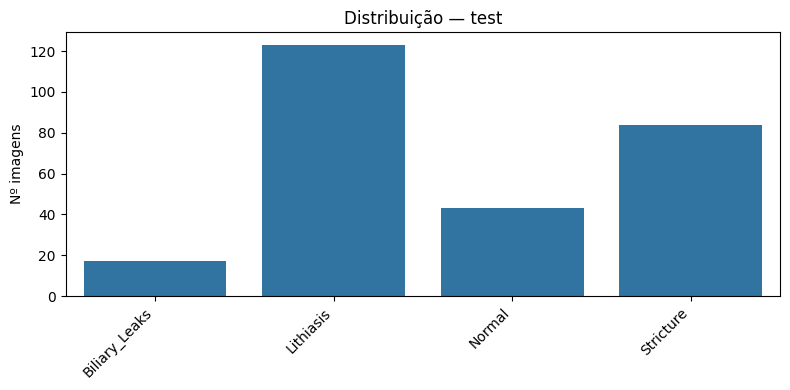

In [5]:

def visualize_balance(labels, class_names, title):
    values, counts = np.unique(labels, return_counts=True)
    labels_ext = [class_names[v] for v in values]
    plt.figure(figsize=(8, 4))
    sns.barplot(x=labels_ext, y=counts)
    plt.title(title)
    plt.ylabel("Nº imagens")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

for phase in phases:
    visualize_balance(data[phase]["labels"], class_names, f"Distribuição — {phase}")


## 5. Dataset e DataLoaders

Usamos resize 256x256 para ResNet, DenseNet, MobileNet e EfficientNet-B0. Para EfficientNet-B7/DeiT pode ser necessário 384x384, mas é mais pesado.


In [6]:

def repeat_if_needed(img):
    # imagens médicas podem vir 1 canal; modelos ImageNet esperam 3 canais
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img

IMG_SIZE = 256
BATCH_SIZE = 4   # sobe para 8/16 se houver memória; baixa para 2 se der OOM
NUM_WORKERS = 0  # no Windows, 0 costuma evitar problemas

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((IMG_SIZE, IMG_SIZE)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor(),
])

class MIQRDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        image_path = self.image_files[index]
        image = self.transforms(image_path)
        label = self.labels[index]
        return image, label, image_path

# Collate para manter paths juntamente com imagens e labels
def collate_fn(batch):
    imgs, labels, paths = zip(*batch)
    return torch.stack(imgs), torch.tensor(labels, dtype=torch.long), list(paths)

test_ds = MIQRDataset(data["test"]["images"], data["test"]["labels"], val_transforms)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)

print("Test batches:", len(test_loader))
imgs, labels, paths = next(iter(test_loader))
print("Batch shape:", imgs.shape)


Test batches: 67
Batch shape: torch.Size([4, 3, 256, 256])


## 6. Funções para criar modelos

Os checkpoints `.pth` guardam `state_dict`, por isso precisamos recriar a arquitetura antes de carregar os pesos.


In [7]:

def build_resnet50(num_class):
    model = models.resnet50(weights=ResNet50_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_class)
    return model


def build_mobilenet_v2(num_class):
    model = models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_class)
    return model


def build_efficientnet_b0(num_class):
    model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_class)
    return model


def build_efficientnet_b7(num_class):
    model = models.efficientnet_b7(weights=EfficientNet_B7_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_class)
    return model


def build_densenet121(num_class):
    model = DenseNet121(
        spatial_dims=2,
        in_channels=3,
        out_channels=num_class,
        pretrained=True,
    )
    return model


def build_deit3_small(num_class):
    if not TIMM_AVAILABLE:
        raise ImportError("timm não está instalado. Faz: pip install timm")
    model = timm.create_model("deit3_small_patch16_384", pretrained=True, in_chans=3)
    model.head = nn.Linear(model.head.in_features, num_class)
    return model

MODEL_REGISTRY = {
    "ResNet50": {
        "path": MODELS_DIR / "resnet50.pth",
        "builder": build_resnet50,
        "input_size": 256,
    },
    "DenseNet121": {
        "path": MODELS_DIR / "densenet.pth",
        "builder": build_densenet121,
        "input_size": 256,
    },
    "MobileNetV2": {
        "path": MODELS_DIR / "mobilenet_v2.pth",
        "builder": build_mobilenet_v2,
        "input_size": 256,
    },
    "EfficientNetB0": {
        "path": MODELS_DIR / "efficientnet_b0.pth",
        "builder": build_efficientnet_b0,
        "input_size": 256,
    },
    "EfficientNetB7": {
        "path": MODELS_DIR / "efficientnet_b7.pth",
        "builder": build_efficientnet_b7,
        "input_size": 256,
    },
    # DeiT usa 384x384. Avalia separadamente se tiveres checkpoint e memória.
    "DeiTIII": {
        "path": MODELS_DIR / "deitiii.pth",
        "builder": build_deit3_small,
        "input_size": 384,
    },
}


## 7. Avaliação de um modelo

In [8]:

def load_checkpoint(model, checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint)
    return model


def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred, y_prob, img_paths = [], [], [], []

    with torch.no_grad():
        for inputs, labels, paths in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())
            img_paths.extend(paths)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }
    return y_true, y_pred, y_prob, img_paths, metrics


def plot_confusion_matrix(y_true, y_pred, class_names, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Matriz de confusão — {model_name}")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    out_path = RESULTS_DIR / f"cm_{model_name}.png"
    plt.savefig(out_path, dpi=300)
    plt.show()
    print("Guardado:", out_path)


## 8. Avaliar todos os checkpoints disponíveis

Este bloco avalia apenas modelos cujo `.pth` existe na pasta `models/`.



A avaliar: ResNet50
Checkpoint: models\resnet50.pth


C:\Users\EVVLE\AppData\Local\Temp\ipykernel_6096\512983664.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


model                            ResNet50
checkpoint            models\resnet50.pth
time_sec                         4.033011
accuracy                         0.573034
precision_macro                   0.58574
recall_macro                     0.441556
f1_macro                         0.465471
precision_weighted               0.576536
recall_weighted                  0.573034
f1_weighted                      0.558381
dtype: object

Classification report:
               precision    recall  f1-score   support

Biliary_Leaks       0.75      0.18      0.29        17
    Lithiasis       0.57      0.72      0.64       123
       Normal       0.36      0.28      0.32        43
    Stricture       0.66      0.60      0.62        84

     accuracy                           0.57       267
    macro avg       0.59      0.44      0.47       267
 weighted avg       0.58      0.57      0.56       267



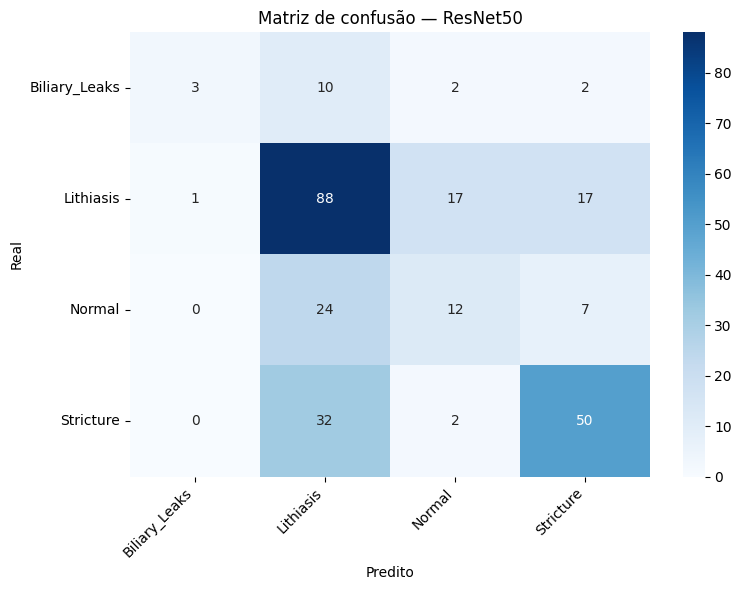

Guardado: results\cm_ResNet50.png

A avaliar: DenseNet121
Checkpoint: models\densenet.pth


C:\Users\EVVLE\AppData\Local\Temp\ipykernel_6096\512983664.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


model                         DenseNet121
checkpoint            models\densenet.pth
time_sec                         5.762411
accuracy                         0.696629
precision_macro                  0.609565
recall_macro                     0.577639
f1_macro                         0.576157
precision_weighted               0.715113
recall_weighted                  0.696629
f1_weighted                      0.692284
dtype: object

Classification report:
               precision    recall  f1-score   support

Biliary_Leaks       0.33      0.18      0.23        17
    Lithiasis       0.73      0.83      0.78       123
       Normal       0.49      0.70      0.58        43
    Stricture       0.88      0.61      0.72        84

     accuracy                           0.70       267
    macro avg       0.61      0.58      0.58       267
 weighted avg       0.72      0.70      0.69       267



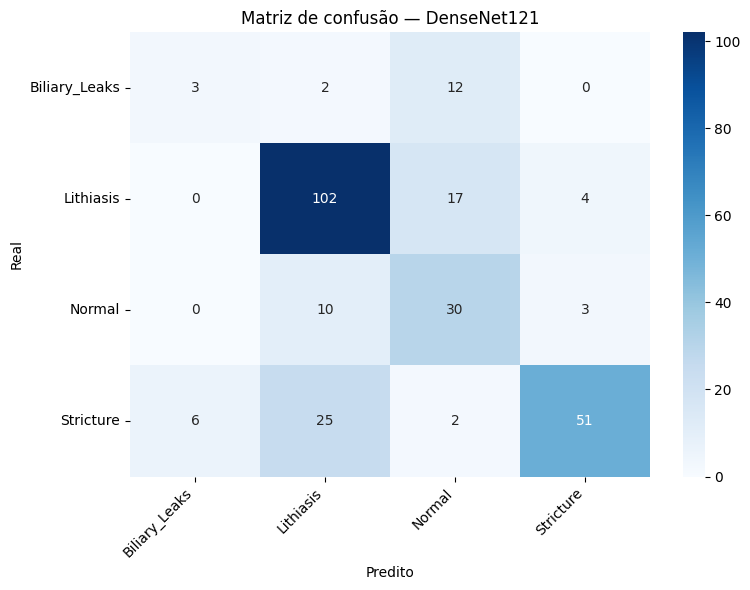

Guardado: results\cm_DenseNet121.png

A avaliar: MobileNetV2
Checkpoint: models\mobilenet_v2.pth


C:\Users\EVVLE\AppData\Local\Temp\ipykernel_6096\512983664.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


model                             MobileNetV2
checkpoint            models\mobilenet_v2.pth
time_sec                             3.716752
accuracy                             0.636704
precision_macro                      0.582315
recall_macro                         0.528305
f1_macro                              0.54764
precision_weighted                   0.629463
recall_weighted                      0.636704
f1_weighted                          0.627013
dtype: object

Classification report:
               precision    recall  f1-score   support

Biliary_Leaks       0.50      0.35      0.41        17
    Lithiasis       0.64      0.78      0.71       123
       Normal       0.47      0.35      0.40        43
    Stricture       0.72      0.63      0.67        84

     accuracy                           0.64       267
    macro avg       0.58      0.53      0.55       267
 weighted avg       0.63      0.64      0.63       267



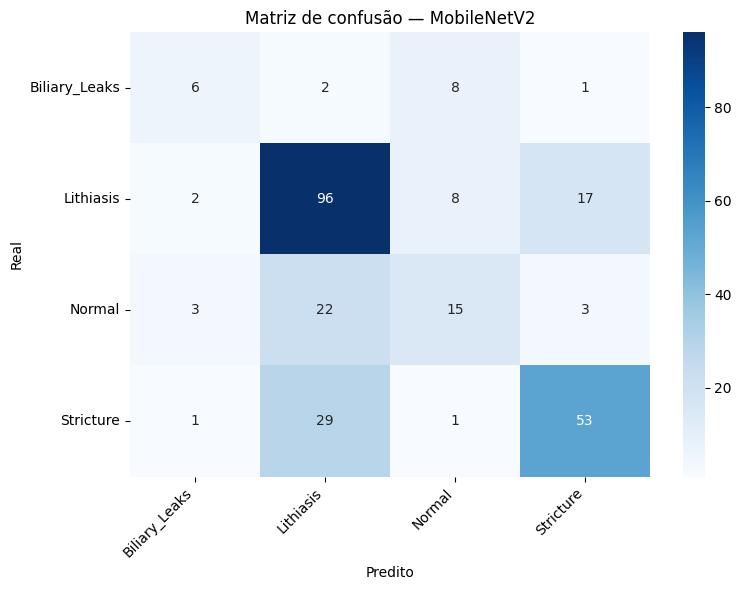

Guardado: results\cm_MobileNetV2.png
[SKIP] EfficientNetB0: não existe models\efficientnet_b0.pth

A avaliar: EfficientNetB7
Checkpoint: models\efficientnet_b7.pth


C:\Users\EVVLE\AppData\Local\Temp\ipykernel_6096\512983664.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


model                             EfficientNetB7
checkpoint            models\efficientnet_b7.pth
time_sec                                8.638185
accuracy                                0.674157
precision_macro                         0.495742
recall_macro                            0.561436
f1_macro                                0.513892
precision_weighted                      0.665662
recall_weighted                         0.674157
f1_weighted                             0.659107
dtype: object

Classification report:
               precision    recall  f1-score   support

Biliary_Leaks       0.00      0.00      0.00        17
    Lithiasis       0.77      0.66      0.71       123
       Normal       0.46      0.84      0.60        43
    Stricture       0.75      0.75      0.75        84

     accuracy                           0.67       267
    macro avg       0.50      0.56      0.51       267
 weighted avg       0.67      0.67      0.66       267



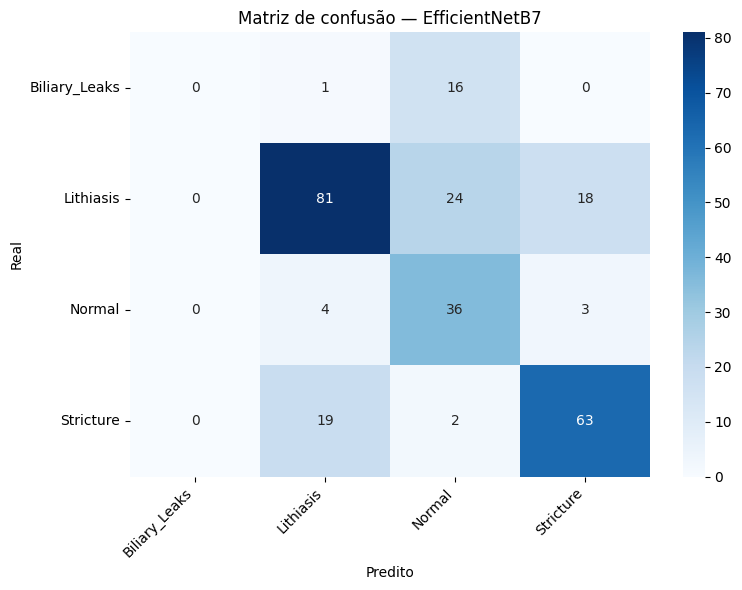

Guardado: results\cm_EfficientNetB7.png
Criando dataloader específico 384x384 para DeiTIII...

A avaliar: DeiTIII
Checkpoint: models\deitiii.pth


C:\Users\EVVLE\AppData\Local\Temp\ipykernel_6096\512983664.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


model                            DeiTIII
checkpoint            models\deitiii.pth
time_sec                        4.381377
accuracy                        0.752809
precision_macro                 0.639366
recall_macro                    0.613011
f1_macro                        0.595171
precision_weighted              0.748871
recall_weighted                 0.752809
f1_weighted                     0.739291
dtype: object

Classification report:
               precision    recall  f1-score   support

Biliary_Leaks       0.33      0.06      0.10        17
    Lithiasis       0.78      0.83      0.81       123
       Normal       0.56      0.81      0.67        43
    Stricture       0.88      0.75      0.81        84

     accuracy                           0.75       267
    macro avg       0.64      0.61      0.60       267
 weighted avg       0.75      0.75      0.74       267



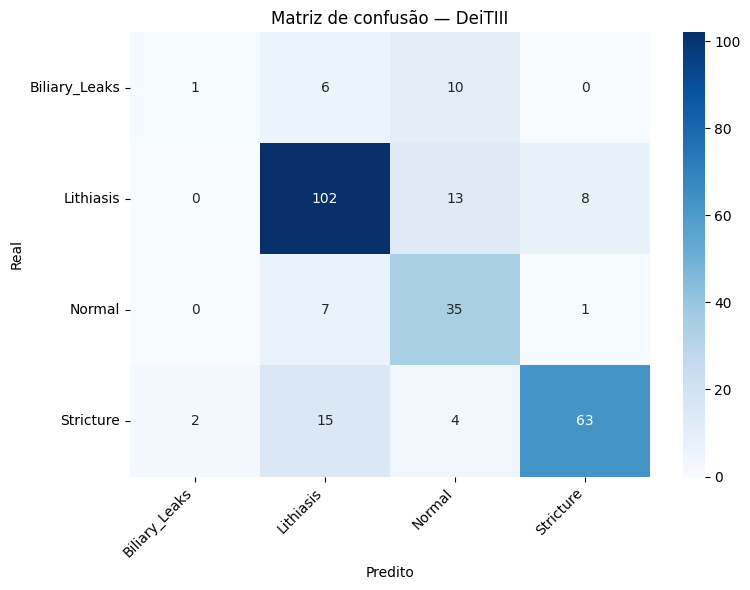

Guardado: results\cm_DeiTIII.png


,model,checkpoint,time_sec,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
4,DeiTIII,models\deitiii.pth,4.381377,0.752809,0.639366,0.613011,0.595171,0.748871,0.752809,0.739291
1,DenseNet121,models\densenet.pth,5.762411,0.696629,0.609565,0.577639,0.576157,0.715113,0.696629,0.692284
2,MobileNetV2,models\mobilenet_v2.pth,3.716752,0.636704,0.582315,0.528305,0.547640,0.629463,0.636704,0.627013
3,EfficientNetB7,models\efficientnet_b7.pth,8.638185,0.674157,0.495742,0.561436,0.513892,0.665662,0.674157,0.659107
0,ResNet50,models\resnet50.pth,4.033011,0.573034,0.585740,0.441556,0.465471,0.576536,0.573034,0.558381


In [9]:

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

all_results = []
all_predictions = {}

for name, cfg in MODEL_REGISTRY.items():
    checkpoint_path = cfg["path"]
    if not checkpoint_path.exists():
        print(f"[SKIP] {name}: não existe {checkpoint_path}")
        continue

    # Se o tamanho de imagem for diferente, criamos um dataloader próprio
    if cfg["input_size"] != IMG_SIZE:
        print(f"Criando dataloader específico {cfg['input_size']}x{cfg['input_size']} para {name}...")
        custom_transforms = Compose([
            LoadImage(image_only=True),
            EnsureChannelFirst(),
            Resize((cfg["input_size"], cfg["input_size"])),
            NormalizeIntensity(),
            Lambda(repeat_if_needed),
            ToTensor(),
        ])
        custom_test_ds = MIQRDataset(data["test"]["images"], data["test"]["labels"], custom_transforms)
        loader_to_use = DataLoader(custom_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)
    else:
        loader_to_use = test_loader

    print("\n==============================")
    print("A avaliar:", name)
    print("Checkpoint:", checkpoint_path)

    model = cfg["builder"](num_class)
    model = load_checkpoint(model, checkpoint_path)
    model = model.to(device)

    start = time.perf_counter()
    y_true, y_pred, y_prob, img_paths, metrics = evaluate_model(model, loader_to_use)
    elapsed = time.perf_counter() - start

    metrics_row = {"model": name, "checkpoint": str(checkpoint_path), "time_sec": elapsed}
    metrics_row.update(metrics)
    all_results.append(metrics_row)
    all_predictions[name] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "paths": img_paths,
    }

    print(pd.Series(metrics_row))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    plot_confusion_matrix(y_true, y_pred, class_names, name)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

results_df = pd.DataFrame(all_results).sort_values("f1_macro", ascending=False)
results_df

## 9. Guardar tabela comparativa

In [10]:

results_path = RESULTS_DIR / "model_comparison_test_metrics.csv"
results_df.to_csv(results_path, index=False)
print("Guardado:", results_path)
results_df


Guardado: results\model_comparison_test_metrics.csv


,model,checkpoint,time_sec,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
4,DeiTIII,models\deitiii.pth,4.381377,0.752809,0.639366,0.613011,0.595171,0.748871,0.752809,0.739291
1,DenseNet121,models\densenet.pth,5.762411,0.696629,0.609565,0.577639,0.576157,0.715113,0.696629,0.692284
2,MobileNetV2,models\mobilenet_v2.pth,3.716752,0.636704,0.582315,0.528305,0.547640,0.629463,0.636704,0.627013
3,EfficientNetB7,models\efficientnet_b7.pth,8.638185,0.674157,0.495742,0.561436,0.513892,0.665662,0.674157,0.659107
0,ResNet50,models\resnet50.pth,4.033011,0.573034,0.585740,0.441556,0.465471,0.576536,0.573034,0.558381


## 10. Comparar com baseline do enunciado

A baseline é **F1 macro = 0.738**. O objetivo é comparar o **F1 macro no test set**.


Melhor modelo: DeiTIII
F1 macro teste: 0.5952
Baseline: 0.738
Diferença: -0.1428


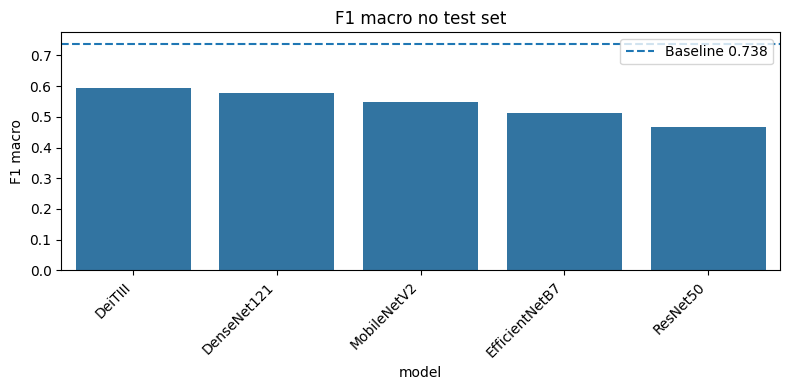

In [11]:

BASELINE_F1 = 0.738
if len(results_df) > 0:
    best = results_df.iloc[0]
    print("Melhor modelo:", best["model"])
    print("F1 macro teste:", round(best["f1_macro"], 4))
    print("Baseline:", BASELINE_F1)
    print("Diferença:", round(best["f1_macro"] - BASELINE_F1, 4))

    plt.figure(figsize=(8,4))
    sns.barplot(data=results_df, x="model", y="f1_macro")
    plt.axhline(BASELINE_F1, linestyle="--", label="Baseline 0.738")
    plt.title("F1 macro no test set")
    plt.ylabel("F1 macro")
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "f1_macro_comparison.png", dpi=300)
    plt.show()


## 11. Mostrar exemplos corretos e errados do melhor modelo

Corretos — DeiTIII


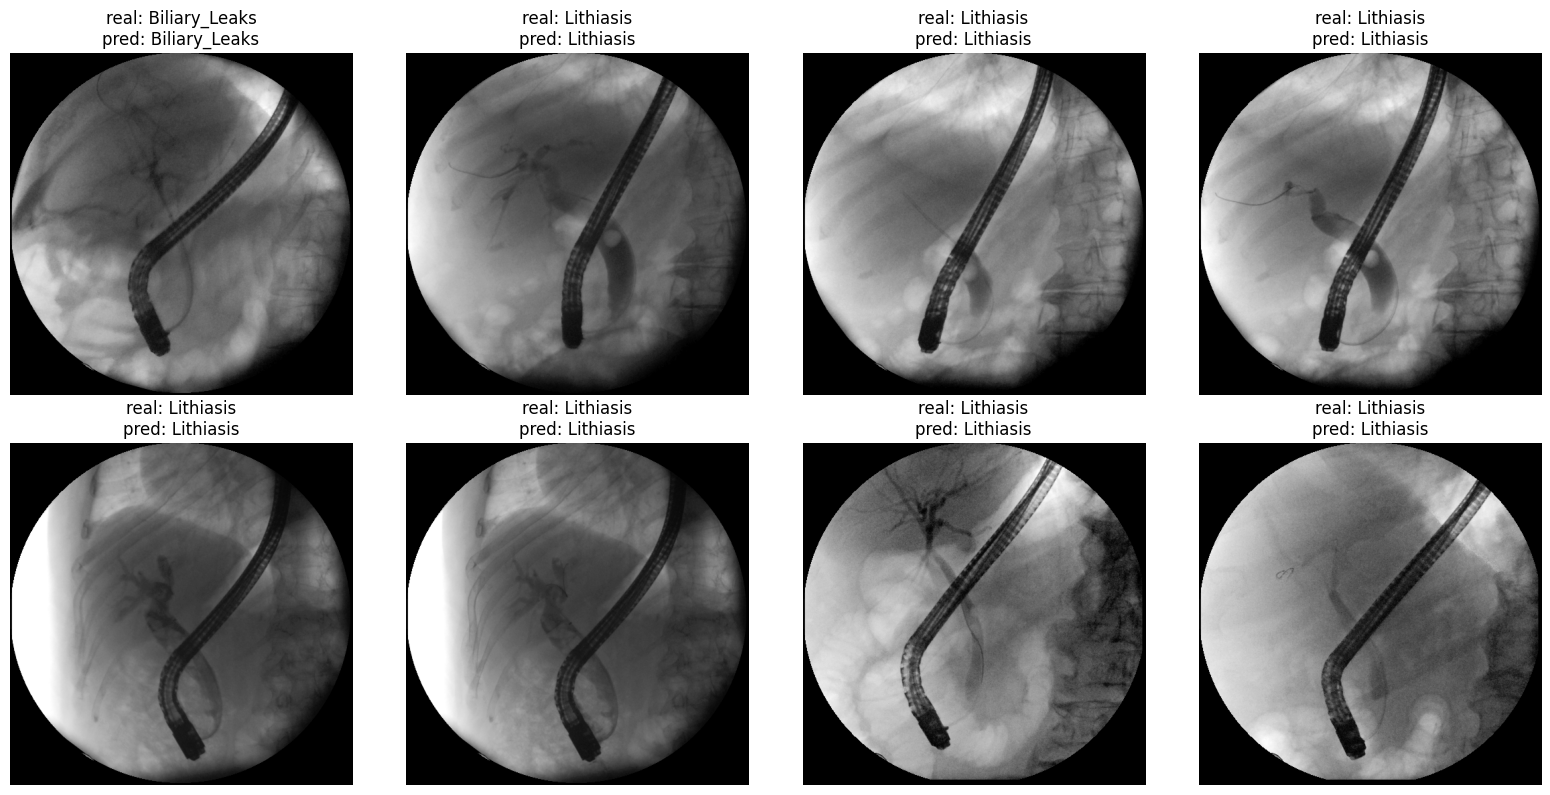

Errados — DeiTIII


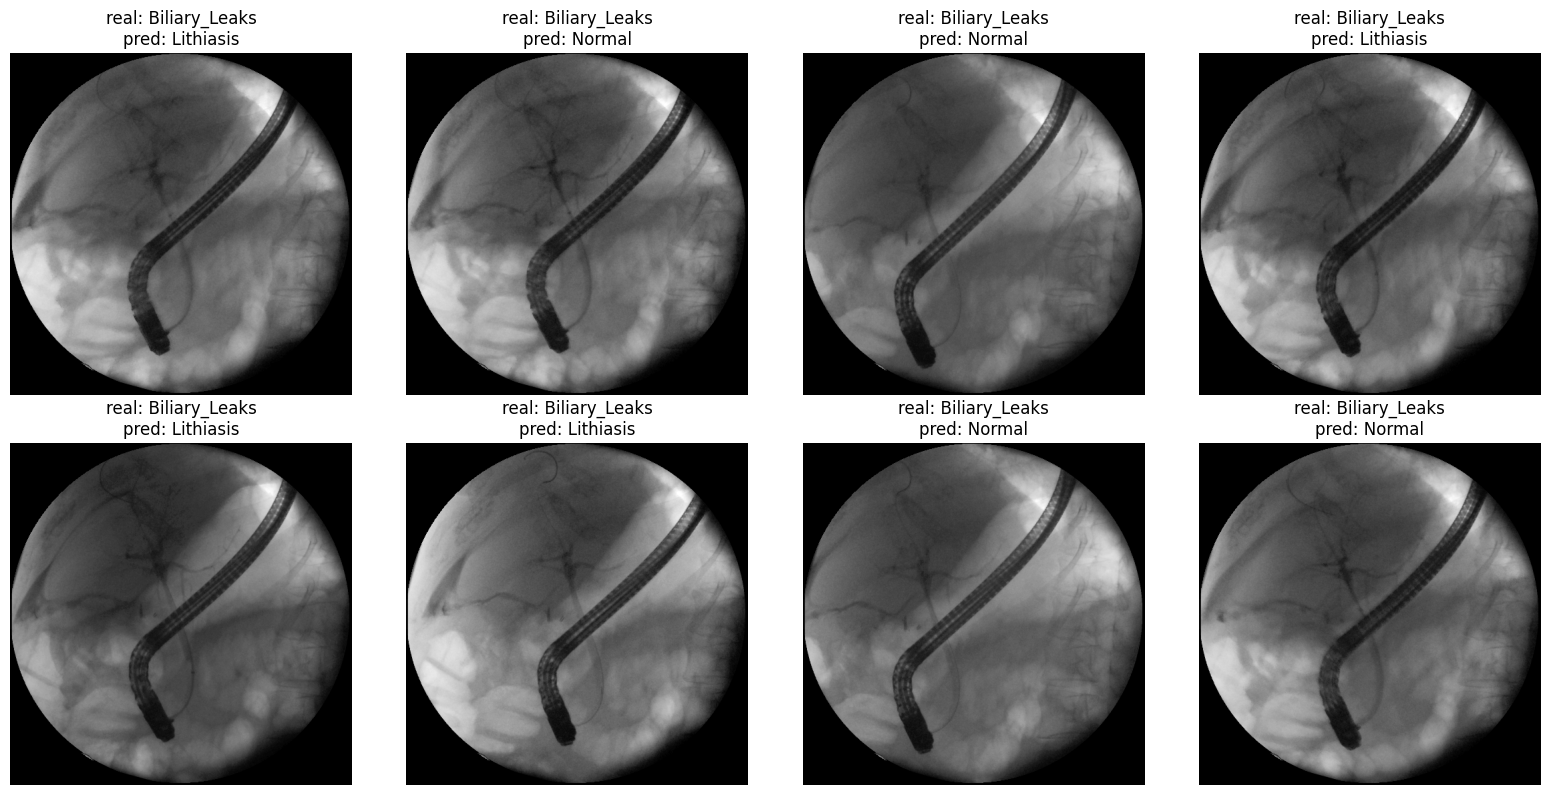

In [12]:

def show_examples(model_name, n=8, correct=True):
    pred_data = all_predictions[model_name]
    y_true = pred_data["y_true"]
    y_pred = pred_data["y_pred"]
    paths = pred_data["paths"]

    mask = (y_true == y_pred) if correct else (y_true != y_pred)
    idxs = np.where(mask)[0]
    if len(idxs) == 0:
        print("Sem exemplos.")
        return
    idxs = idxs[:n]

    cols = min(4, len(idxs))
    rows = int(np.ceil(len(idxs) / cols))
    plt.figure(figsize=(4*cols, 4*rows))
    for i, idx in enumerate(idxs):
        img = Image.open(paths[idx]).convert("L")
        plt.subplot(rows, cols, i+1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")
        plt.title(f"real: {class_names[y_true[idx]]}\npred: {class_names[y_pred[idx]]}")
    plt.tight_layout()
    plt.show()

if len(results_df) > 0:
    best_model_name = results_df.iloc[0]["model"]
    print("Corretos —", best_model_name)
    show_examples(best_model_name, correct=True)
    print("Errados —", best_model_name)
    show_examples(best_model_name, correct=False)


## 12. Grad-CAM

Se der erro nesta secção, instala:

```bash
pip install grad-cam
```

A ideia é gerar mapas de calor para perceber se o modelo está a olhar para a zona clinicamente relevante.


In [13]:

try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    GRADCAM_AVAILABLE = True
except Exception as e:
    GRADCAM_AVAILABLE = False
    print("Grad-CAM não disponível:", e)


Grad-CAM não disponível: No module named 'pytorch_grad_cam'


In [14]:

def get_target_layer(model, model_name):
    # target layers típicas por arquitetura
    if model_name == "ResNet50":
        return [model.layer4[-1]]
    if model_name == "MobileNetV2":
        return [model.features[-1]]
    if model_name == "EfficientNetB0" or model_name == "EfficientNetB7":
        return [model.features[-1]]
    if model_name == "DenseNet121":
        return [model.features[-1]]
    raise ValueError(f"Target layer não definido para {model_name}")


def preprocess_image_for_cam(path, img_size=IMG_SIZE):
    # tensor igual ao dataloader
    tensor = val_transforms(path).unsqueeze(0).to(device)

    # imagem para overlay [0,1], RGB
    pil = Image.open(path).convert("RGB").resize((img_size, img_size))
    rgb_img = np.array(pil).astype(np.float32) / 255.0
    return tensor, rgb_img


def plot_gradcam(model_name, image_path, target_class=None):
    if not GRADCAM_AVAILABLE:
        print("Instala primeiro: pip install grad-cam")
        return

    cfg = MODEL_REGISTRY[model_name]
    model = cfg["builder"](num_class)
    model = load_checkpoint(model, cfg["path"])
    model = model.to(device)
    model.eval()

    input_tensor, rgb_img = preprocess_image_for_cam(image_path, img_size=IMG_SIZE)

    with torch.no_grad():
        outputs = model(input_tensor)
        pred_class = int(outputs.argmax(dim=1).item())

    if target_class is None:
        target_class = pred_class

    target_layers = get_target_layer(model, model_name)
    cam = GradCAM(model=model, target_layers=target_layers)
    grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(target_class)])[0]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(rgb_img)
    plt.axis("off")
    plt.title("Imagem original")

    plt.subplot(1,2,2)
    plt.imshow(visualization)
    plt.axis("off")
    plt.title(f"Grad-CAM\npred: {class_names[pred_class]} | target: {class_names[target_class]}")
    plt.tight_layout()
    plt.show()

    del model, cam
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


In [15]:

# Exemplo Grad-CAM para o melhor modelo, num caso errado se existir; senão, num correto.
if GRADCAM_AVAILABLE and len(results_df) > 0:
    best_model_name = results_df.iloc[0]["model"]
    pred_data = all_predictions[best_model_name]
    y_true = pred_data["y_true"]
    y_pred = pred_data["y_pred"]
    paths = pred_data["paths"]

    wrong_idxs = np.where(y_true != y_pred)[0]
    idx = int(wrong_idxs[0]) if len(wrong_idxs) else 0

    print("Modelo:", best_model_name)
    print("Path:", paths[idx])
    print("Real:", class_names[y_true[idx]])
    print("Pred:", class_names[y_pred[idx]])

    plot_gradcam(best_model_name, paths[idx], target_class=int(y_pred[idx]))


## 13. Notas para relatório

Regista no relatório:

- preprocessamento usado: resize, normalização, conversão para 3 canais;
- modelos avaliados;
- F1 macro no test set;
- comparação com baseline 0.738;
- matriz de confusão do melhor modelo;
- exemplos Grad-CAM corretos e errados;
- análise de falsos negativos em classes patológicas.
